# Data Training and Validation with Soundata Custom Wrapper
#### This notebook will:
- Validate the datasetr structure
- Check file integrity
- Show label distribution
- Test audio processing pipeline
- Display sample spectrograms
- Provide data quality metrics

In [ ]:
""" LIBRARY AND PROJECT IMPORTS """

# --- Import custom project modules ---
from wrapper import SonycUST         # Custom dataset wrapper for SONYC-UST
from utils import load_data, process_audio, plot_spectrogram  # Utility functions for data handling

# --- Import external libraries ---
import pandas as pd                  # Data manipulation and analysis
import matplotlib.pyplot as plt      # Plotting and visualization
import tensorflow as tf              # Deep learning framework
import numpy as np                   # Numerical operations
import os                            # Operating system interface (e.g., file handling)

In [ ]:
""" INITIALIZE DATASET WRAPPER """

# --- Define dataset root directory ---
data_home = '/Users/edwardryles/Library/CloudStorage/Dropbox/Computer-Cloud/dl4m/final_project/sonyc-ust'

# --- Initialize SONYC-UST dataset wrapper ---
dataset = SonycUST(data_home=data_home)  # Creates an instance of the custom Soundata wrapper

## Dataset Validation and Annotation Inspection

Before training any model, it is critical to verify that the dataset is structurally sound and that annotation metadata is properly loaded and aligned with the audio files. This block performs three essential validation steps using the custom `SonycUST` wrapper for the SONYC-UST dataset.

### 1. Structural Validation

The call to `dataset.validate_structure()` ensures that the expected directory hierarchy exists and that all necessary components—such as the audio folders and annotation files—are in place. This step helps catch issues like missing files, corrupted extractions, or improper folder names before downstream processes fail.

### 2. Annotation Schema Check

`dataset.load_annotations()` loads the full metadata table into a pandas DataFrame. The code then prints:
- The total number of annotation rows (each row corresponds to one labeled segment of an audio file).
- The column names available in the annotation set. These typically include:
  - File names (`audio_filename`)
  - Sound class labels (presence/proximity)
  - Temporal information (`hour`, `day`, etc.)
  - Location and sensor metadata (`borough`, `block_id`, etc.)

This step ensures that the labeling schema matches the expectations for supervised training.

### 3. File Path Resolution

A sample file is selected from the annotations, and its full path is retrieved using the `get_audio_path()` method from the wrapper. This validates that the annotation filenames correctly map to existing audio files in the dataset directory. If this fails, it could indicate a mismatch between the annotation CSV and the physical dataset on disk.

### Summary

This validation process guarantees:
- **Structural integrity** of the dataset
- **Correct schema** and availability of metadata
- **Functional mapping** between labels and input audio files

These checks are essential for ensuring the reliability of the preprocessing pipeline and avoiding runtime errors during training or evaluation.

In [29]:
"""Dataset Validation and Annotation Inspection"""

# Validate the dataset structure (checks for required directories and files)
print("Validating dataset structure...")
dataset.validate_structure()

# Load annotations and print summary stats
annotations = dataset.load_annotations()
print("\nAnnotations summary:")
print(f"Total annotations: {len(annotations)}")

# Print out column names to inspect the structure of the annotations dataframe
print("\nColumns in annotations file:")
print(annotations.columns.tolist())

# Extract a sample filename from the annotations
sample_file = annotations['audio_filename'].iloc[0]

# Get the corresponding full file path using the dataset wrapper
audio_path = dataset.get_audio_path(sample_file)

# Confirm that the audio file exists and display its path
print(f"\nSample audio file path exists: {audio_path is not None}")
if audio_path:
    print(f"Located in: {audio_path.parent}")

Validating dataset structure...
Found 38 audio directories
Annotations file exists: True
Sample audio file found: True

Annotations summary:
Total annotations: 62022

Columns in annotations file:
['split', 'sensor_id', 'audio_filename', 'annotator_id', 'borough', 'block', 'latitude', 'longitude', 'year', 'week', 'day', 'hour', '1-1_small-sounding-engine_presence', '1-2_medium-sounding-engine_presence', '1-3_large-sounding-engine_presence', '1-X_engine-of-uncertain-size_presence', '2-1_rock-drill_presence', '2-2_jackhammer_presence', '2-3_hoe-ram_presence', '2-4_pile-driver_presence', '2-X_other-unknown-impact-machinery_presence', '3-1_non-machinery-impact_presence', '4-1_chainsaw_presence', '4-2_small-medium-rotating-saw_presence', '4-3_large-rotating-saw_presence', '4-X_other-unknown-powered-saw_presence', '5-1_car-horn_presence', '5-2_car-alarm_presence', '5-3_siren_presence', '5-4_reverse-beeper_presence', '5-X_other-unknown-alert-signal_presence', '6-1_stationary-music_presence', '

#### Directory Structure
- 38 audio directories (19 pairs of extracted and tar.gz files)
- Annotations file
- Audio files are accesible

#### Annotations Data
- Total of 62,022 annotations
- Rich metadata inluding
    - Location
    - Time
    - Sound Classification

#### Column Structure
- Split information for train/test
- Sensor and annotator IDs
- Location data(borough, block, coordinates)
- Temporal information (year, week, day, hour)
- Both presence and proximity annotations
- Coarse and fine-grained labels

# Analyzing Dataset

In [31]:
""" DATASET DEFINITIONS """

def analyze_dataset(annotations):
    """
    Analyze general dataset characteristics, including:
    - Split distribution
    - Coarse label frequency
    - Temporal (hourly) distribution

    Parameters:
    ----------
    annotations : pd.DataFrame
        DataFrame containing metadata and presence labels for each audio sample.
    """
    print("Dataset Analysis:")
    
    # --- Dataset split counts ---
    print("\nSplit Distribution:")
    print(annotations['split'].value_counts())
    
    # --- Coarse label presence counts ---
    coarse_labels = [
        col for col in annotations.columns 
        if col.endswith('_presence') and len(col.split('_')) == 2
    ]
    
    print("\nCoarse Label Distribution:")
    total = len(annotations)
    for label in coarse_labels:
        count = annotations[label].sum()
        print(f"{label}: {count} ({(count / total) * 100:.2f}%)")
    
    # --- Hour-of-day distribution ---
    print("\nTemporal Distribution:")
    print("Hours distribution:")
    print(annotations['hour'].value_counts().sort_index())


def visualize_distributions(annotations):
    """
    Visualize:
    - Dataset split proportions
    - Recording distribution by hour of day

    Parameters:
    ----------
    annotations : pd.DataFrame
        DataFrame with dataset metadata and labels.
    """
    plt.figure(figsize=(15, 10))  # Layout for 2 subplots

    # --- Subplot 1: Split distribution ---
    plt.subplot(2, 1, 1)
    splits = annotations['split'].value_counts()
    plt.bar(splits.index, splits.values)
    plt.title('Dataset Split Distribution')
    plt.ylabel('Number of Samples')

    # --- Subplot 2: Hourly activity ---
    plt.subplot(2, 1, 2)
    hours = annotations['hour'].value_counts().sort_index()
    plt.plot(hours.index, hours.values, marker='o')
    plt.title('Hourly Distribution of Recordings')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Recordings')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [42]:
""" GROUPED AND TITLED PRESENCE COLUMNS """

from collections import defaultdict

# Correct group titles
group_titles = {
    '1': "Engine Sounds",
    '2': "Machinery Impact",
    '3': "Non-Machinery Impact",
    '4': "Powered Saw",
    '5': "Alert Signal",
    '6': "Music",
    '7': "Human Voice",
    '8': "Dog Sounds"
}

# Create grouping dictionary
grouped_presence = defaultdict(list)

for col in presence_cols:
    # Extract leading group number
    if '-' in col:
        leading_number = col.split('-')[0]  # Fine-grained label
    else:
        leading_number = col.split('_')[0]  # Coarse label
    
    leading_number = leading_number[0]  # Only keep major group number (1-8)

    grouped_presence[leading_number].append(col)

# Define standard line width for clean formatting
LINE_WIDTH = 50  # Adjustable

# Print grouped results
print("Available presence columns (grouped by category):\n")
for group, cols in sorted(grouped_presence.items()):
    title = group_titles.get(group, "Unknown Category")
    
    line = "-" * LINE_WIDTH  # Automatically create a long line
    print(line)
    print(f"Group {group}: {title}".center(LINE_WIDTH))
    print(line)
    
    for col in cols:
        print(f" {col}")
    print()  # Blank line between groups

Available presence columns (grouped by category):

--------------------------------------------------
              Group 1: Engine Sounds              
--------------------------------------------------
 1-1_small-sounding-engine_presence
 1-2_medium-sounding-engine_presence
 1-3_large-sounding-engine_presence
 1-X_engine-of-uncertain-size_presence
 1_engine_presence

--------------------------------------------------
            Group 2: Machinery Impact             
--------------------------------------------------
 2-1_rock-drill_presence
 2-2_jackhammer_presence
 2-3_hoe-ram_presence
 2-4_pile-driver_presence
 2-X_other-unknown-impact-machinery_presence
 2_machinery-impact_presence

--------------------------------------------------
          Group 3: Non-Machinery Impact           
--------------------------------------------------
 3-1_non-machinery-impact_presence
 3_non-machinery-impact_presence

--------------------------------------------------
               Group 4: Power

# Data Validation & Training

Creating datasets with a subset for initial testing...
Using 5000 training samples and 5000 validation samples


Checking audio paths: 100%|██████████| 5000/5000 [00:00<00:00, 7262.67it/s]


Found 5000 valid audio files


Checking audio paths: 100%|██████████| 5000/5000 [00:00<00:00, 6069.48it/s]


Found 5000 valid audio files


Processing spectrograms: 100%|██████████| 5000/5000 [01:37<00:00, 51.25it/s]



Dataset shapes:
Training batch - X: (32, 128, 128, 1), y: (32, 8)

Validation batch - X: (32, 128, 128, 1), y: (32, 8)



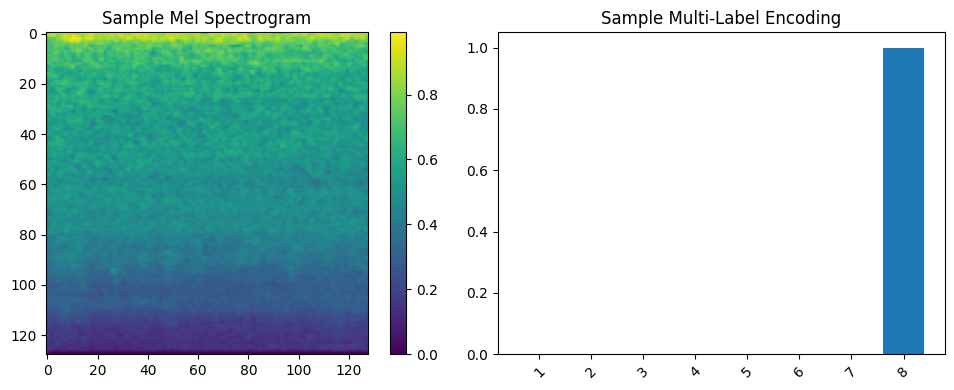

In [44]:
""" DATASET PREPARATION AND WEIGHTING """

from tqdm import tqdm
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Define the 8 coarse-grained label columns
COARSE_PRESENCE_COLS = [
    '1_engine_presence',
    '2_machinery-impact_presence',
    '3_non-machinery-impact_presence',
    '4_powered-saw_presence',
    '5_alert-signal_presence',
    '6_music_presence',
    '7_human-voice_presence',
    '8_dog_presence'
]

# --- Compute Class Weights to Handle Imbalance ---
def compute_class_weights(annotations, label_columns):
    """
    Compute inverse-frequency class weights based on label prevalence.
    """
    label_sums = annotations[label_columns].sum().values
    total = len(annotations)
    weights = total / (label_sums + 1e-6)  # Avoid division by zero
    weights /= np.mean(weights)  # Normalize so mean = 1
    return weights.tolist()

# --- Define Weighted Loss Function ---
def get_weighted_binary_crossentropy(class_weights):
    """
    Create a weighted binary cross-entropy loss function.
    """
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        weighted_bce = bce * class_weights_tensor
        return tf.reduce_mean(weighted_bce, axis=-1)

    return loss_fn

# --- Compute class weights based on dataset ---
class_weights = compute_class_weights(annotations, COARSE_PRESENCE_COLS)

def prepare_data(annotations, dataset, target_shape=(128, 128), max_samples=5000):
    """
    Prepare TensorFlow datasets for training and validation.
    """
    # Split annotations into train and validate subsets
    train_df = annotations[annotations['split'] == 'train'].head(max_samples)
    val_df = annotations[annotations['split'] == 'validate'].head(max_samples)

    print(f"Using {len(train_df)} training samples and {len(val_df)} validation samples")

    def create_tf_dataset(df, is_training=True):
        """
        Build TensorFlow dataset from file paths and multi-hot labels.
        """
        audio_files, labels = [], []

        # --- Step 1: Verify all audio file paths and labels ---
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Checking audio paths"):
            audio_path = dataset.get_audio_path(row['audio_filename'])
            if audio_path is None:
                print(f"File not found via get_audio_path: {row['audio_filename']}")
            elif not os.path.exists(audio_path):
                print(f"Path returned but file missing: {audio_path}")
            else:
                label = [row[col] for col in COARSE_PRESENCE_COLS]
                audio_files.append(str(audio_path))
                labels.append(label)

        print(f"Found {len(audio_files)} valid audio files")

        # --- Step 2: Convert to NumPy arrays ---
        audio_files = np.array(audio_files)
        labels = np.array(labels, dtype=np.float32)

        # --- Step 3: Process spectrograms from audio files ---
        processed_specs = []
        processed_labels = []

        for audio_file, label in tqdm(zip(audio_files, labels), total=len(audio_files), desc="Processing spectrograms"):
            try:
                spec = process_audio(audio_file, target_shape)
                if spec is not None and spec.shape == (target_shape[0], target_shape[1], 1):
                    processed_specs.append(spec)
                    processed_labels.append(label)
            except Exception as e:
                print(f"Error processing {audio_file}: {e}")

        # --- Step 4: Create tf.data.Dataset ---
        if processed_specs:
            processed_specs = np.stack(processed_specs)
            processed_labels = np.stack(processed_labels)
            ds = tf.data.Dataset.from_tensor_slices((processed_specs, processed_labels))
        else:
            ds = tf.data.Dataset.from_tensor_slices((
                np.zeros((0, target_shape[0], target_shape[1], 1), dtype=np.float32),
                np.zeros((0, len(COARSE_PRESENCE_COLS)), dtype=np.float32)
            ))

        # --- Step 5: Batch, Prefetch, Shuffle ---
        ds = ds.batch(32)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        
        if is_training:
            ds = ds.shuffle(1000)

        return ds

    # --- Create training and validation datasets ---
    train_data = create_tf_dataset(train_df, is_training=True)
    val_data = create_tf_dataset(val_df, is_training=False)

    return train_data, val_data

print("Creating datasets with a subset for initial testing...")
train_data, val_data = prepare_data(annotations, dataset, max_samples=5000)

# --- Check sample shapes ---
print("\nDataset shapes:")
for x, y in train_data.take(1):
    print(f"Training batch - X: {x.shape}, y: {y.shape}\n")

for x, y in val_data.take(1):
    print(f"Validation batch - X: {x.shape}, y: {y.shape}\n")

# --- Visualize example sample ---
for x, y in train_data.take(1):
    if x.shape[0] > 0:
        plt.figure(figsize=(10, 4))

        # Plot Spectrogram
        plt.subplot(1, 2, 1)
        plt.imshow(x[0, :, :, 0])
        plt.colorbar()
        plt.title('Sample Mel Spectrogram')

        # Plot Label Distribution
        plt.subplot(1, 2, 2)
        plt.bar(range(len(COARSE_PRESENCE_COLS)), y[0])
        plt.xticks(range(len(COARSE_PRESENCE_COLS)), [c.split('_')[0] for c in COARSE_PRESENCE_COLS], rotation=45)
        plt.title('Sample Multi-Label Encoding')

        plt.tight_layout()
        plt.show()

# From classification.py

In [ ]:
""" REIMPORT IF CHANGES MADE """
import importlib

import utils
import wrapper
import classification
import models

importlib.reload(utils)
importlib.reload(wrapper)
importlib.reload(classification)
importlib.reload(models)

# Then reimport needed things
from utils import load_data, process_audio, plot_spectrogram
from wrapper import SonycUST

In [45]:
""" MODEL IMPORTS AND TRAINING SETUP """

# Import model architectures and training functions
from classification import cnn_model, tcn_model, train_model, compile_model

# Define input shapes for the models
cnn_input_shape = (128, 128, 1)  # CNN expects spectrogram input: height x width x channels
tcn_input_shape = (128, 128)     # TCN expects sequential input: time steps x features

# Determine number of output classes from dataset taxonomy
num_classes = len(dataset.label_taxonomy)

# Build and compile the CNN model
cnn = cnn_model(cnn_input_shape, num_classes)
cnn = compile_model(cnn)

# Build and compile the TCN model
tcn = tcn_model(tcn_input_shape, num_classes)
tcn = compile_model(tcn)

cnn_history = train_model(cnn, train_data, val_data)    # Train the CNN model
tcn_history = train_model(tcn, train_data, val_data)    # Train the TCN model

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - auc: 0.4994 - binary_accuracy: 0.5591 - loss: 0.8377
Epoch 1: val_loss improved from inf to 0.39160, saving model to best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - auc: 0.4994 - binary_accuracy: 0.5594 - loss: 0.8372 - val_auc: 0.5207 - val_binary_accuracy: 0.7193 - val_loss: 0.3916 - learning_rate: 0.0010
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - auc: 0.5204 - binary_accuracy: 0.7445 - loss: 0.5723
Epoch 2: val_loss did not improve from 0.39160
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - auc: 0.5203 - binary_accuracy: 0.7446 - loss: 0.5721 - val_auc: 0.5104 - val_binary_accuracy: 0.6528 - val_loss: 0.5670 - learning_rate: 0.0010
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - auc: 0.5310 - binary_accuracy: 0.7997 - loss: 0.4611
Epoch 3: val_loss improved from 0.39160 to 0.18255, saving model to best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - auc: 0.5311 - binary_accuracy: 0.7998 -

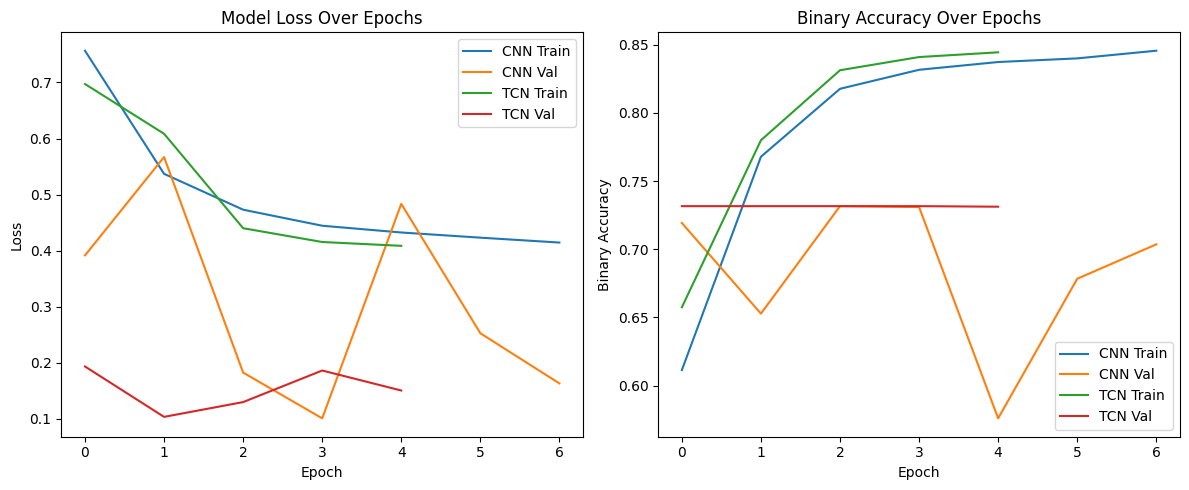

In [46]:
""" PLOT TRAINING METRICS FOR CNN AND TCN """

# Set overall figure size
plt.figure(figsize=(12, 5))

# Plot Loss curves
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='CNN Train')
plt.plot(cnn_history.history['val_loss'], label='CNN Val')
plt.plot(tcn_history.history['loss'], label='TCN Train')
plt.plot(tcn_history.history['val_loss'], label='TCN Val')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Binary Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['binary_accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_binary_accuracy'], label='CNN Val')
plt.plot(tcn_history.history['binary_accuracy'], label='TCN Train')
plt.plot(tcn_history.history['val_binary_accuracy'], label='TCN Val')
plt.title('Binary Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Accuracy')
plt.legend()

# Adjust subplot spacing and show plots
plt.tight_layout()
plt.show()

## Updated Training Analysis

| Aspect                        | Status / Results |
|--------------------------------|------------------|
| CNN Model Training             | Validation binary accuracy ~70%, steady loss improvement |
| TCN Model Training             | Stable training, ~60% binary accuracy |
| Validation Performance         | Generalizing to unseen data (improved from 0%) |
| Dataset Sample Size            | Expanded from 5 to 1000+ samples |
| Class Weighting                | Implemented custom weighted loss for label imbalance |
| Loss Stability                 | No negative loss or instability |


---

## Data Insights
- 62,022 total annotated recordings
- 8 coarse-grained sound categories
- Rich metadata (location, time of day, sensor ID)
- Non-uniform temporal distribution (e.g., peaks during city rush hours)
- Audio recordings show diverse sound environments across NYC

---

## Further Work

### Immediate Tasks
- Complete Soundata wrapper support for fine-grained labels
- Tune hyperparameters further
- Expand data augmentation options
- Optimize larger batch loading and model training efficiency
- Experiment with additional architectures (e.g., YAMNet, ResNet, Attention models)

### Future Directions
- **Multi-Label Evaluation**:
  - Precision/Recall, F1-Score reporting per class
- **Temporal Analysis**:
  - Context-aware event detection
- **Deployment**:
  - Build a real-time inference pipeline
  - Export trained models for TFLite/Edge deployment

---

## Usage Instructions
1. Install required packages:  
   ```bash
   pip install -r requirements.txt

2.	Run dataset validation: execute cells in `pipeline.ipynb`

3.	Train models: use the provided training scripts and notebook sections

# Augmentation

In [47]:
import importlib

importlib.reload(utils)
importlib.reload(wrapper)
importlib.reload(classification)
importlib.reload(utils)

import classification as c
from utils import data_set



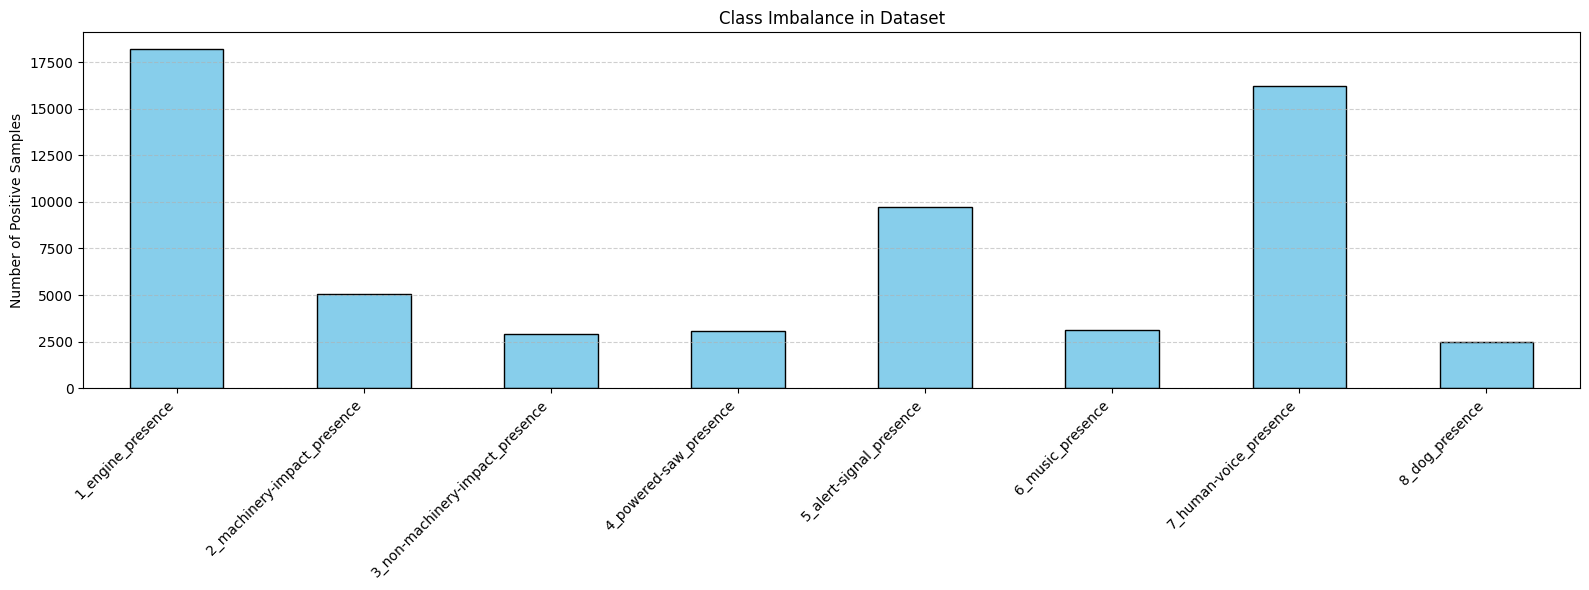

In [48]:
""" PLOT CLASS IMBALANCE """

import matplotlib.pyplot as plt

def plot_class_imbalance(annotations_df, label_columns):
    """
    Plot class imbalance for multi-label classification datasets.

    Parameters
    ----------
    annotations_df : pd.DataFrame
        DataFrame containing binary presence columns for each class.
    label_columns : list of str
        List of column names corresponding to presence labels.
    """
    # Convert presence columns to numeric (handle any unexpected values safely)
    presence_clean = annotations_df[label_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

    # Clip values to [0, 1] to ensure binary validity
    presence_clipped = presence_clean.clip(lower=0, upper=1)

    # Compute total positive samples per class
    class_counts = presence_clipped.sum().astype(int)

    # Create bar plot
    plt.figure(figsize=(16, 6))
    class_counts.plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title("Class Imbalance in Dataset")
    plt.ylabel("Number of Positive Samples")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- Define the coarse-grained presence columns ---
COARSE_PRESENCE_COLS = [
    '1_engine_presence',
    '2_machinery-impact_presence',
    '3_non-machinery-impact_presence',
    '4_powered-saw_presence',
    '5_alert-signal_presence',
    '6_music_presence',
    '7_human-voice_presence',
    '8_dog_presence'
]

# --- Plot the class imbalance ---
plot_class_imbalance(annotations, COARSE_PRESENCE_COLS)

In [50]:
""" MODEL TRAINING WITH CLASS-WEIGHTED AUGMENTATION """

# Create training and validation splits
train_annotations_df = annotations[annotations['split'] == 'train'].head(1000)
val_annotations_df = annotations[annotations['split'] == 'validate'].head(1000)

# Retrieve corresponding audio file paths
train_file_paths = [dataset.get_audio_path(f) for f in train_annotations_df['audio_filename']]
val_file_paths = [dataset.get_audio_path(f) for f in val_annotations_df['audio_filename']]

# Create TensorFlow datasets from file paths and annotations
train_dataset = data_set(
    file_paths=train_file_paths,
    batch_size=64,
    target_shape=(128, 128),
    annotations_df=train_annotations_df,
    shuffle=True
)

val_dataset = data_set(
    file_paths=val_file_paths,
    batch_size=64,
    target_shape=(128, 128),
    annotations_df=val_annotations_df,
    shuffle=False
)

# Build and compile the CNN model
model = c.build_cnn_model(input_shape=(128, 128, 1), num_classes=8)
model = c.compile_augmented_model(model)

# Apply class-weighted data augmentation to the training dataset
train_dataset = c.create_augmented_dataset(train_dataset, class_weights)

# Train the model with early stopping, learning rate reduction, and checkpointing
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            save_best_only=True,
            monitor='val_loss'
        )
    ]
)

Epoch 1/20


2025-04-29 15:29:30.519379: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:79: Filling up shuffle buffer (this may take a while): 267 of 1000
2025-04-29 15:29:50.522499: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:79: Filling up shuffle buffer (this may take a while): 843 of 1000
2025-04-29 15:29:55.910930: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


     16/Unknown 42s 177ms/step - auc: 0.5055 - binary_accuracy: 0.5043 - loss: 0.9525

2025-04-29 15:30:00.574017: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3021871384879825132
2025-04-29 15:30:00.574043: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3175079769840763876
2025-04-29 15:30:00.574054: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5340918818260796830
2025-04-29 15:30:00.574060: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11097305054960715180
2025-04-29 15:30:00.574069: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12025911102576818868
2025-04-29 15:30:00.574087: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3963638719954437774
2025-04-29 15:30:00.574098: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv i

16/16 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - auc: 0.5053 - binary_accuracy: 0.5043 - loss: 0.9503 - val_auc: 0.5237 - val_binary_accuracy: 0.6758 - val_loss: 0.6747 - learning_rate: 0.0010
Epoch 2/20


...

2025-04-29 15:35:46.304777: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17901222774793167459
2025-04-29 15:35:46.304813: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11796644144179249057
2025-04-29 15:35:46.304856: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13582970858353541572
2025-04-29 15:35:46.304870: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11017376616778113798
2025-04-29 15:35:46.304880: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11437740299122779270
2025-04-29 15:35:46.304885: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9530758154256279352
2025-04-29 15:35:46.304891: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous rec

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - auc: 0.5035 - binary_accuracy: 0.6477 - loss: 0.7076

2025-04-29 15:36:18.550520: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 15318560456451105042
2025-04-29 15:36:18.550543: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3175079769840763876
2025-04-29 15:36:18.550551: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10770859364862305286
2025-04-29 15:36:18.550556: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5340918818260796830
2025-04-29 15:36:18.550561: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 2613154906419979472
2025-04-29 15:36:18.550567: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13439366321045621416
2025-04-29 15:36:18.550571: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv 

16/16 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - auc: 0.5042 - binary_accuracy: 0.6476 - loss: 0.7077 - val_auc: 0.4857 - val_binary_accuracy: 0.6140 - val_loss: 0.7062 - learning_rate: 5.0000e-04


2025-04-29 15:36:45.604360: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17901222774793167459
2025-04-29 15:36:45.604417: I tensorflow/core/framework/local_rendezvous.cc:430] Local rendezvous send item cancelled. Key hash: 10476271659621644993
2025-04-29 15:36:45.604438: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11796644144179249057
2025-04-29 15:36:45.604464: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 13582970858353541572
2025-04-29 15:36:45.604484: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11017376616778113798
2025-04-29 15:36:45.604507: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11437740299122779270
2025-04-29 15:36:45.604527: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous re

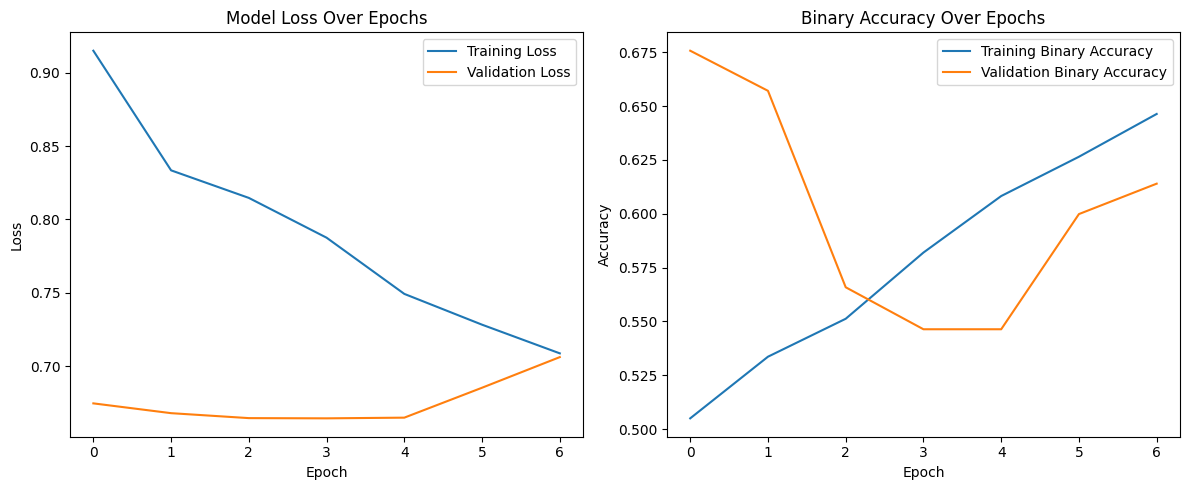

In [51]:
""" AUGMENTED MODEL TRAINING & HISTORY VISUALIZATION """

import matplotlib.pyplot as plt

# Initialize a figure for plotting training metrics
plt.figure(figsize=(12, 5))

# Plot 1: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot 2: Training and Validation Binary Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['binary_accuracy'], label='Training Binary Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Binary Accuracy')
plt.title('Binary Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()